# SMM StateGraph

Linear LangGraph workflow (see 
eference/smm.png):

START → Data Extractor → Account Scrapper and prompt modifier → Execute Prompt 1…6 → END


In [82]:
import os
import csv
import json
import re
import glob
import logging
import time
from datetime import date, datetime
from functools import wraps
from typing import Any, Callable, Optional
from typing_extensions import TypedDict

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_community.document_loaders import TextLoader
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from apify_client import ApifyClient
from langgraph.graph import END, StateGraph, START

load_dotenv()

assert os.getenv("APIFY_API_KEY"), "APIFY_API_KEY not loaded - check that .env exists and load_dotenv() ran before using it"

# ---------------------------------------------------------------------------
# LLM provider switch: "openai" | "groq"
# TPM / input truncation is enforced ONLY for Groq free-tier limits.
# ---------------------------------------------------------------------------
LLM_PROVIDER = "openai"

# Groq free/on_demand TPM for openai/gpt-oss-120b is 8000 (input + completion).
GROQ_TPM_LIMIT = 8000
GROQ_MAX_COMPLETION_TOKENS = 1500
GROQ_TOKEN_SAFETY_MARGIN = 300

if LLM_PROVIDER == "groq":
    assert os.getenv("GROQ_API_KEY"), "GROQ_API_KEY not loaded - required when LLM_PROVIDER='groq'"
    os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
    ENFORCE_TPM_LIMIT = True
    MAX_COMPLETION_TOKENS = GROQ_MAX_COMPLETION_TOKENS
    MAX_INPUT_TOKENS = GROQ_TPM_LIMIT - MAX_COMPLETION_TOKENS - GROQ_TOKEN_SAFETY_MARGIN  # 6200
    llm = ChatGroq(
        model_name="openai/gpt-oss-120b",
        temperature=0.7,
        max_tokens=MAX_COMPLETION_TOKENS,
    )
elif LLM_PROVIDER == "openai":
    assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not loaded - required when LLM_PROVIDER='openai'"
    os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
    ENFORCE_TPM_LIMIT = False
    MAX_COMPLETION_TOKENS = None  # no artificial TPM-driven completion cap
    MAX_INPUT_TOKENS = None
    llm = ChatOpenAI(
        model_name="gpt-5.6-luna",
        temperature=0.7,
    )
else:
    raise ValueError(f"Unsupported LLM_PROVIDER={LLM_PROVIDER!r}; use 'openai' or 'groq'")

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)-7s | %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
logger = logging.getLogger("smm.graph")
logger.info(
    "LLM provider=%s enforce_tpm=%s max_input=%s max_completion=%s",
    LLM_PROVIDER,
    ENFORCE_TPM_LIMIT,
    MAX_INPUT_TOKENS,
    MAX_COMPLETION_TOKENS,
)
llm.invoke("Hello, how are you?")


2026-08-01 22:33:56 | INFO    | LLM provider=openai enforce_tpm=False max_input=None max_completion=None
2026-08-01 22:33:59 | INFO    | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


AIMessage(content='Hello! I’m doing well, thank you. How are you?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 12, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 'id': 'chatcmpl-E87PqJl62hlzZOM5DAtXy5e7sEWVp', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fbe48-48e9-75e0-a9fc-f5fa4d1a8465-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 17, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [83]:
class profile_metadata(BaseModel):
    username: str = Field(description="The username of the Instagram profile")
    description: str = Field(description="The description or bio of the Instagram profile")
    reels: list[str] = Field(description="The urls of the reels of the Instagram profile")


class smm_metadata(BaseModel):
    subject: profile_metadata = Field(description="The subject of the Instagram profile")
    competitors: list[profile_metadata] = Field(description="The competitors of the Instagram profile")
    important_accounts: list[profile_metadata] = Field(
        default_factory=list,
        description="Accounts the creator wants their content to look/feel exactly like",
    )


class insta_profile(BaseModel):
    username: str = Field(description="The username of the Instagram profile")
    full_name: str = Field(description="The full/display name of the Instagram profile")
    followers: int = Field(description="The number of followers of the Instagram profile")
    following: int = Field(description="The number of people the user is following")
    posts_count: int = Field(description="The number of posts the user has made")
    bio: str = Field(description="The bio of the Instagram profile")
    profile_picture: str = Field(description="The profile picture of the Instagram profile")
    posts: list[str] = Field(description="The urls of the recent posts/reels selected for analysis")


In [84]:
apify_api_key = os.getenv("APIFY_API_KEY")
if not apify_api_key:
    raise ValueError("APIFY_API_KEY not found in environment - check .env and that load_dotenv() has run")

apify_client = ApifyClient(apify_api_key)

# ---------------------------------------------------------------------------
# Tunable scrape limit — change this to control how many recent reels/posts
# are retrieved per account for DNA scraping and downstream analysis.
# ---------------------------------------------------------------------------
REELS_PER_ACCOUNT = 10

# Same-day scrape log sheet — prevents scraping the same account twice per day.
SCRAPE_LOG_DIR = "logs"
SCRAPE_LOG_PATH = os.path.join(SCRAPE_LOG_DIR, "scrape_log.csv")
SCRAPE_LOG_FIELDS = ["date", "username", "role", "json_path", "scraped_at"]


def _dataset_id(run) -> str:
    if isinstance(run, dict):
        return run["defaultDatasetId"]
    return getattr(run, "default_dataset_id", None) or run["defaultDatasetId"]


def _normalize_username(username: str) -> str:
    return (username or "").lstrip("@").strip()


def _today_str() -> str:
    return date.today().isoformat()


def dna_json_path(role: str, username: str) -> str:
    return os.path.join("dna", role, f"{_normalize_username(username)}.json")


def _ensure_scrape_log() -> None:
    os.makedirs(SCRAPE_LOG_DIR, exist_ok=True)
    if not os.path.isfile(SCRAPE_LOG_PATH):
        with open(SCRAPE_LOG_PATH, "w", newline="", encoding="utf-8") as f:
            csv.DictWriter(f, fieldnames=SCRAPE_LOG_FIELDS).writeheader()


def _read_scrape_log() -> list[dict]:
    _ensure_scrape_log()
    with open(SCRAPE_LOG_PATH, "r", newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def record_scrape(username: str, role: str, json_path: str) -> None:
    """Append one row to the scrape log sheet for today's scrape."""
    _ensure_scrape_log()
    now = datetime.now()
    row = {
        "date": now.date().isoformat(),
        "username": _normalize_username(username),
        "role": role,
        "json_path": json_path.replace("\\", "/"),
        "scraped_at": now.isoformat(timespec="seconds"),
    }
    with open(SCRAPE_LOG_PATH, "a", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=SCRAPE_LOG_FIELDS).writerow(row)
    logger.info("[scrape-log] recorded %s/%s for %s -> %s", role, row["username"], row["date"], row["json_path"])


def was_scraped_today(username: str, role: str | None = None) -> Optional[str]:
    """
    Return path to today's DNA JSON for this account if it already exists.
    Checks the log sheet first, then falls back to DNA file mtime for the same day.
    """
    username = _normalize_username(username)
    today = _today_str()

    for row in reversed(_read_scrape_log()):
        if row.get("date") != today:
            continue
        if _normalize_username(row.get("username", "")) != username:
            continue
        if role and row.get("role") != role:
            continue
        path = (row.get("json_path") or "").replace("/", os.sep)
        if path and os.path.isfile(path):
            return path

    roles = [role] if role else ["subject", "competitors", "important"]
    for r in roles:
        if not r:
            continue
        path = dna_json_path(r, username)
        if not os.path.isfile(path):
            continue
        mtime_day = datetime.fromtimestamp(os.path.getmtime(path)).date().isoformat()
        if mtime_day == today:
            return path
    return None


def load_insta_profile_from_json(json_path: str) -> "insta_profile":
    """Rebuild insta_profile from a saved dna/<role>/{username}.json."""
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    profile = data.get("profile") or {}
    post_urls: list[str] = []
    for post in data.get("posts") or []:
        url = post.get("url") or post.get("inputUrl") or ""
        if url:
            post_urls.append(url)
    return insta_profile(
        username=profile.get("username") or os.path.splitext(os.path.basename(json_path))[0],
        full_name=profile.get("full_name", ""),
        followers=int(profile.get("followers") or 0),
        following=int(profile.get("following") or 0),
        posts_count=int(profile.get("posts_count") or 0),
        bio=profile.get("bio", ""),
        profile_picture=profile.get("profile_picture", ""),
        posts=post_urls,
    )


def _is_reel(post: dict) -> bool:
    """Best-effort Instagram reel/video detection from profile-scraper fields."""
    post_type = str(post.get("type") or "").lower()
    product = str(post.get("productType") or "").lower()
    return (
        post_type in {"video", "reel", "clips"}
        or product in {"clips", "reels", "reel"}
        or bool(post.get("videoUrl"))
        or post.get("videoViewCount") is not None
    )


def _select_reel_urls(latest_posts: list[dict], limit: int) -> list[str]:
    """Prefer reels/videos; if fewer than limit, fill with other latest posts."""
    with_url = [p for p in latest_posts if p.get("url")]
    reels = [p for p in with_url if _is_reel(p)]
    others = [p for p in with_url if not _is_reel(p)]

    selected = reels[:limit]
    if len(selected) < limit:
        selected.extend(others[: limit - len(selected)])
    return [p["url"] for p in selected]


def get_insta_profile(username: str, reels_limit: int = REELS_PER_ACCOUNT) -> insta_profile:
    username = _normalize_username(username)
    cached_path = was_scraped_today(username)
    if cached_path:
        logger.info(
            "[Apify] skip profile scrape for %s — already scraped today (%s)",
            username,
            cached_path,
        )
        return load_insta_profile_from_json(cached_path)

    run_input = {"usernames": [username]}
    run = apify_client.actor("apify/instagram-profile-scraper").call(run_input=run_input)
    items = list(apify_client.dataset(_dataset_id(run)).iterate_items())

    if not items:
        raise ValueError(f"No profile data found for username: {username}")

    data = items[0]
    post_urls = _select_reel_urls(data.get("latestPosts", []) or [], reels_limit)
    logger.info(
        "[Apify] %s: selected %d/%d reel/post URLs (REELS_PER_ACCOUNT=%d)",
        username,
        len(post_urls),
        reels_limit,
        reels_limit,
    )

    return insta_profile(
        username=data.get("username", username),
        full_name=data.get("fullName", ""),
        followers=data.get("followersCount", 0),
        following=data.get("followsCount", 0),
        posts_count=data.get("postsCount", 0),
        bio=data.get("biography", ""),
        profile_picture=data.get("profilePicUrl", ""),
        posts=post_urls,
    )


def scrape_profile_reels(
    profile: insta_profile,
    role: str,
    reels_limit: int = REELS_PER_ACCOUNT,
) -> list[dict]:
    """Fetch up to `reels_limit` recent posts/reels and persist under dna/<role>/{username}.json."""
    if role not in {"subject", "competitors", "important"}:
        raise ValueError(f"Unknown role: {role!r}")

    output_dir = os.path.join("dna", role)
    os.makedirs(output_dir, exist_ok=True)
    output_path = dna_json_path(role, profile.username)

    cached_path = was_scraped_today(profile.username, role=role)
    if cached_path and os.path.isfile(cached_path):
        logger.info(
            "[Apify] skip reel scrape for %s/%s — already scraped today (%s)",
            role,
            profile.username,
            cached_path,
        )
        if os.path.abspath(cached_path) != os.path.abspath(output_path):
            with open(cached_path, "r", encoding="utf-8") as f:
                data = json.load(f)
            with open(output_path, "w", encoding="utf-8") as f:
                json.dump(data, f, indent=2, ensure_ascii=False)
            cached_path = output_path
        with open(cached_path, "r", encoding="utf-8") as f:
            return (json.load(f).get("posts") or [])[:reels_limit]

    urls = list(profile.posts or [])[:reels_limit]
    if not urls:
        items = []
    else:
        run_input = {
            "resultsType": "posts",
            "directUrls": urls,
            "resultsLimit": reels_limit,
        }
        run = apify_client.actor("apify/instagram-scraper").call(run_input=run_input)
        items = list(apify_client.dataset(_dataset_id(run)).iterate_items())
        items = items[:reels_limit]

    logger.info(
        "[Apify] scraped %d items for %s/%s (limit=%d)",
        len(items),
        role,
        profile.username,
        reels_limit,
    )

    output_data = {
        "profile": {
            "username": profile.username,
            "full_name": profile.full_name,
            "bio": profile.bio,
            "followers": profile.followers,
            "following": profile.following,
            "posts_count": profile.posts_count,
            "profile_picture": profile.profile_picture,
        },
        "posts": items,
        "scraped_at": datetime.now().isoformat(timespec="seconds"),
        "scrape_date": _today_str(),
    }

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(output_data, f, indent=2, ensure_ascii=False)

    record_scrape(profile.username, role, output_path)
    return items


In [85]:
PROMPT_1_PATH = os.path.join("prompts", "Prompt 1- content DNA intake prompt.md")
PROMPT_2_PATH = os.path.join("prompts", "instagram-content-intelligence-engine.md")
PROMPT_3_PATH = os.path.join("prompts", "live-performance-learning-engine.md")
PROMPT_4_PATH = os.path.join("prompts", "content-opportunity-prioritization-engine.md")
PROMPT_5_PATH = os.path.join("prompts", "performance-script-execution-engine.md")
PROMPT_6_PATH = os.path.join("prompts", "Prompt 6 — Viral Script Amplification Engine.docx.md")

INTAKE_START_MARKER = "<!-- CONTENT_DNA_INTAKE_START -->"
INTAKE_END_MARKER = "<!-- CONTENT_DNA_INTAKE_END -->"
OUTPUT_DIR = "output"
# Groq-only TPM budgeting. OpenAI keeps full prior/DNA context.
if ENFORCE_TPM_LIMIT:
    MAX_PRIOR_CHARS = 2500
    MAX_DNA_CHARS = 9000
else:
    MAX_PRIOR_CHARS = None
    MAX_DNA_CHARS = None
MAX_POSTS_PER_PROFILE = REELS_PER_ACCOUNT  # keep DNA analysis aligned with scrape limit
MAX_CAPTION_CHARS = 280


# --- Stage logging -----------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)
logger = logging.getLogger("smm.graph")


def log_stage(stage_name: str) -> Callable:
    """Decorator that logs when a graph stage starts and ends (with duration)."""

    def decorator(fn: Callable) -> Callable:
        @wraps(fn)
        def wrapper(state: dict, *args, **kwargs):
            started_at = datetime.now()
            started_ts = started_at.strftime("%Y-%m-%d %H:%M:%S")
            logger.info("[%s] STARTED at %s", stage_name, started_ts)
            t0 = time.perf_counter()
            try:
                result = fn(state, *args, **kwargs)
            except Exception:
                elapsed = time.perf_counter() - t0
                ended_at = datetime.now()
                logger.exception(
                    "[%s] FAILED at %s (duration: %.2fs | started: %s)",
                    stage_name,
                    ended_at.strftime("%Y-%m-%d %H:%M:%S"),
                    elapsed,
                    started_ts,
                )
                raise
            elapsed = time.perf_counter() - t0
            ended_at = datetime.now()
            logger.info(
                "[%s] ENDED at %s (duration: %.2fs | started: %s)",
                stage_name,
                ended_at.strftime("%Y-%m-%d %H:%M:%S"),
                elapsed,
                started_ts,
            )
            return result

        return wrapper

    return decorator



def load_prompt(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


def extract_final_prompt(path: str) -> str:
    """Return only the executable system prompt from a prompt markdown file."""
    text = load_prompt(path)

    markers = [
        "## **Final Prompt — Copy and Paste This Exactly**",
        "3) ## **Final prompt**",
        "## **Final prompt**",
    ]
    start = -1
    for marker in markers:
        idx = text.find(marker)
        if idx != -1:
            start = idx + len(marker)
            break

    if start == -1:
        you_are = text.find("You are the")
        return text[you_are:].strip() if you_are != -1 else text.strip()

    body = text[start:].lstrip("\n")
    lines = body.splitlines()
    while lines and (
        not lines[0].strip()
        or set(lines[0].strip()) <= {"-", "─", "—", "=", "*"}
    ):
        lines.pop(0)
    body = "\n".join(lines).strip()

    # Prompt 6 wraps the copy/paste block between long separators
    sep = "─────────────────────────────────────────────────────────"
    if sep in body:
        if body.startswith(sep):
            body = body[len(sep):].lstrip("\n")
        close_idx = body.find(sep)
        if close_idx != -1:
            body = body[:close_idx].rstrip()

    you_are = body.find("You are the")
    if you_are > 0:
        body = body[you_are:]
    return body.strip()


def reset_role_dir(role: str, keep_usernames: set[str] | None = None) -> None:
    """Ensure dna/<role> exists; drop stale JSON but keep same-day scrapes we will reuse."""
    role_dir = os.path.join("dna", role)
    os.makedirs(role_dir, exist_ok=True)
    keep = {_normalize_username(u) for u in (keep_usernames or set())}
    for path in glob.glob(os.path.join(role_dir, "*.json")):
        username = os.path.splitext(os.path.basename(path))[0]
        if username in keep and was_scraped_today(username, role=role):
            logger.info("[dna] keeping same-day cache %s/%s", role, username)
            continue
        os.remove(path)


def load_role_profiles(role: str) -> list[dict]:
    paths = sorted(glob.glob(os.path.join("dna", role, "*.json")))
    loaded = []
    for path in paths:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        profile = data.get("profile", {}) or {}
        username = profile.get("username") or os.path.splitext(os.path.basename(path))[0]
        loaded.append({"username": username, "profile": profile, "posts": data.get("posts", [])})
    return loaded


def _slim_profile(profile: dict) -> dict:
    """Keep only fields needed for DNA analysis; drop bulky URLs."""
    return {
        "username": profile.get("username") or "",
        "full_name": profile.get("full_name") or "",
        "bio": (profile.get("bio") or "")[:300],
        "followers": profile.get("followers"),
        "following": profile.get("following"),
        "posts_count": profile.get("posts_count"),
    }


def _slim_posts(posts: list[dict]) -> list[dict]:
    slimmed = []
    for post in posts[:MAX_POSTS_PER_PROFILE]:
        slimmed.append(
            {
                "url": post.get("url") or post.get("displayUrl") or "",
                "caption": (post.get("caption") or "")[:MAX_CAPTION_CHARS],
                "hashtags": (post.get("hashtags") or [])[:10],
                "likesCount": post.get("likesCount"),
                "commentsCount": post.get("commentsCount"),
                "videoViewCount": post.get("videoViewCount"),
                "videoPlayCount": post.get("videoPlayCount"),
                "timestamp": post.get("timestamp"),
                "type": post.get("type") or post.get("productType"),
            }
        )
    return slimmed


def build_dna_bundle() -> str:
    """Serialize scraped dna/ JSON for LLM context (no filesystem access needed)."""
    bundle = {
        "subject": [
            {
                "username": f["username"],
                "profile": _slim_profile(f["profile"]),
                "posts": _slim_posts(f["posts"]),
            }
            for f in load_role_profiles("subject")
        ],
        "competitors": [
            {
                "username": f["username"],
                "profile": _slim_profile(f["profile"]),
                "posts": _slim_posts(f["posts"]),
            }
            for f in load_role_profiles("competitors")
        ],
        "important": [
            {
                "username": f["username"],
                "profile": _slim_profile(f["profile"]),
                "posts": _slim_posts(f["posts"]),
            }
            for f in load_role_profiles("important")
        ],
    }
    # Compact JSON saves ~30% tokens vs indent=2
    text = json.dumps(bundle, ensure_ascii=False, separators=(",", ":"))
    if MAX_DNA_CHARS is not None and len(text) > MAX_DNA_CHARS:
        text = text[:MAX_DNA_CHARS] + "\n... [dna bundle truncated]"
    return text



def _post_engagement_score(post: dict) -> float:
    likes = post.get("likesCount") or 0
    comments = post.get("commentsCount") or 0
    views = post.get("videoViewCount") or 0
    plays = post.get("videoPlayCount") or 0
    try:
        return float(likes) + (2.0 * float(comments)) + (0.001 * float(views or plays))
    except (TypeError, ValueError):
        return 0.0


def build_performance_data(top_n: int = 15) -> str:
    """Build Prompt 3 performance brief from scraped dna/ engagement metrics.

    Uses public scrape metrics (likes, comments, views, plays) - not private
    Instagram Insights (saves/reach/profile visits).
    """
    sections = [
        "LIVE PERFORMANCE DATA (from scraped Instagram posts)",
        "Source note: Public Apify/scrape metrics only. Do not invent Insights fields",
        "(saves, reach, profile visits, watch time) that are not listed below.",
        "",
    ]
    any_posts = False
    for role in ("subject", "competitors", "important"):
        profiles = load_role_profiles(role)
        if not profiles:
            continue
        sections.append(f"## Role: {role}")
        for f in profiles:
            username = f.get("username") or "unknown"
            profile = f.get("profile") or {}
            posts = list(f.get("posts") or [])
            if not posts:
                sections.append(f"### @{username}")
                sections.append("- No posts available in scrape.")
                sections.append("")
                continue
            any_posts = True
            ranked = sorted(posts, key=_post_engagement_score, reverse=True)[:top_n]
            sections.append(f"### @{username}")
            sections.append(
                f"- followers: {profile.get('followers')} | posts_count: {profile.get('posts_count')}"
            )
            sections.append(
                f"- top {len(ranked)} posts by engagement proxy "
                "(likes + 2*comments + views/plays):"
            )
            for idx, post in enumerate(ranked, 1):
                caption = (post.get("caption") or "").replace("\n", " ").strip()
                if len(caption) > 160:
                    caption = caption[:157] + "..."
                ptype = post.get("type") or post.get("productType") or "unknown"
                sections.append(
                    f"  {idx}. type={ptype} | likes={post.get('likesCount')} | "
                    f"comments={post.get('commentsCount')} | "
                    f"views={post.get('videoViewCount')} | "
                    f"plays={post.get('videoPlayCount')} | ts={post.get('timestamp')}"
                )
                sections.append(f"     url: {post.get('url') or post.get('displayUrl') or ''}")
                if caption:
                    sections.append(f"     caption: {caption}")
            sections.append("")
    if not any_posts:
        return ""
    text = "\n".join(sections).strip()
    if MAX_DNA_CHARS is not None and len(text) > MAX_DNA_CHARS:
        text = text[:MAX_DNA_CHARS] + "\n... [performance_data truncated]"
    return text


def infer_niche_summary(profile: dict, posts: list[dict]) -> tuple[str, bool]:
    bio = (profile.get("bio") or "").strip()
    if bio:
        return bio, False

    captions = [p.get("caption", "") for p in posts if p.get("caption")]
    hashtags = sorted({h for p in posts for h in p.get("hashtags", [])})
    if not captions and not hashtags:
        return "", False

    context = "\n".join(captions[:10]) + "\n\nHashtags: " + ", ".join(hashtags[:20])
    response = llm.invoke(
        "Based only on the following Instagram captions and hashtags, write a "
        "faithful 1-2 line summary of this creator's niche, topic area, and "
        "audience. Do not invent details not supported by the text:\n\n" + context
    )
    return response.content.strip(), True


def build_content_dna_intake() -> str:
    subject_files = load_role_profiles("subject")
    competitor_files = load_role_profiles("competitors")
    important_files = load_role_profiles("important")

    missing_fields = []
    data_quality_notes = []

    if not subject_files:
        subject_username = "No Account created yet"
        niche_summary = ""
        missing_fields.append("Creator Account Username / Niche Summary (dna/subject/ is empty)")
    else:
        if len(subject_files) > 1:
            data_quality_notes.append(
                f"Multiple files found in dna/subject/ ({[f['username'] for f in subject_files]}); using the first one."
            )
        subject = subject_files[0]
        subject_username = subject["username"]
        niche_summary, inferred = infer_niche_summary(subject["profile"], subject["posts"])
        if inferred:
            data_quality_notes.append(
                "Niche Summary inferred from post captions/hashtags (no bio available)."
            )
        if not niche_summary:
            missing_fields.append("Niche Summary")

    def dedupe_usernames(files):
        seen = []
        for f in files:
            if f["username"] not in seen:
                seen.append(f["username"])
        return seen

    competitor_usernames = dedupe_usernames(competitor_files)
    important_usernames = dedupe_usernames(important_files)

    overlap = sorted(set(competitor_usernames) & set(important_usernames))
    if overlap:
        data_quality_notes.append(
            "Usernames found in both dna/competitors/ and dna/important/ "
            f"(Needs verification): {', '.join(overlap)}"
        )

    if not competitor_usernames:
        missing_fields.append("Competitor Account usernames (dna/competitors/ is empty)")
    if not important_usernames:
        data_quality_notes.append("No important accounts provided - continuing without them.")

    lines = [
        "CONTENT DNA INTAKE",
        f"Creator Account Username: {subject_username}",
        f"Niche Summary: {niche_summary}",
        f"Competitor Account usernames: {', '.join(competitor_usernames) if competitor_usernames else 'None'}",
        f"Any Important Account usernames: {', '.join(important_usernames) if important_usernames else 'None'}",
        "Extra Notes: NA",
        f"Missing or Not Provided Fields: {', '.join(missing_fields) if missing_fields else 'None'}",
        f"Data Quality Notes: {', '.join(data_quality_notes) if data_quality_notes else 'None'}",
    ]
    return "\n".join(lines)


def write_intake_into_prompt(content_dna_intake: str, prompt_path: str = PROMPT_1_PATH) -> None:
    with open(prompt_path, "r", encoding="utf-8") as f:
        prompt_text = f.read()

    if INTAKE_START_MARKER not in prompt_text or INTAKE_END_MARKER not in prompt_text:
        raise ValueError(
            f"Could not find intake markers in {prompt_path}. "
            "Add CONTENT_DNA_INTAKE_START/END markers before running."
        )

    pattern = re.compile(
        re.escape(INTAKE_START_MARKER) + r".*?" + re.escape(INTAKE_END_MARKER),
        re.DOTALL,
    )
    replacement = f"{INTAKE_START_MARKER}\n{content_dna_intake}\n{INTAKE_END_MARKER}"
    new_prompt_text, count = pattern.subn(replacement, prompt_text)
    if count != 1:
        raise ValueError(f"Expected exactly one marker block in {prompt_path}, found {count}.")

    with open(prompt_path, "w", encoding="utf-8") as f:
        f.write(new_prompt_text)


def _profile_to_dict(profile: Any) -> dict:
    if isinstance(profile, insta_profile):
        return profile.model_dump()
    if isinstance(profile, dict):
        return profile
    return {}


def _truncate(text: str, limit: int | None = MAX_PRIOR_CHARS) -> str:
    text = text or ""
    if limit is None or len(text) <= limit:
        return text
    return text[:limit] + "\n... [truncated]"


def format_prior_context(state: dict, include_keys: list[str], include_dna: bool = True) -> str:
    sections = []
    if include_dna and state.get("dna_bundle"):
        sections.append(f"### dna_bundle\n{state['dna_bundle']}")
    for key in include_keys:
        value = state.get(key)
        if value:
            sections.append(f"### {key}\n{_truncate(str(value))}")
    if not sections:
        return "No prior pipeline outputs were available. Proceed using only the system prompt."
    return (
        "Prior pipeline outputs follow. Use them as authoritative inputs for this stage.\n"
        "If Important Accounts are None/empty, continue without them — do not invent any.\n\n"
        + "\n\n".join(sections)
    )


def _estimate_tokens(text: str) -> int:
    """Rough token estimate (chars/4). Good enough for TPM budgeting."""
    return max(1, (len(text or "") + 3) // 4)


def _fit_to_input_budget(system_prompt: str, human: str) -> tuple[str, str]:
    """Truncate the human message so system+human stay under MAX_INPUT_TOKENS (Groq only)."""
    if not ENFORCE_TPM_LIMIT or MAX_INPUT_TOKENS is None:
        return system_prompt, human

    sys_tokens = _estimate_tokens(system_prompt)
    human_budget = MAX_INPUT_TOKENS - sys_tokens
    if human_budget < 200:
        # System prompt alone is large — leave a tiny human stub so the call still runs.
        logger.warning(
            "System prompt alone is ~%d tokens; human context will be heavily truncated",
            sys_tokens,
        )
        human_budget = 200

    human_char_budget = human_budget * 4
    if len(human or "") > human_char_budget:
        human = (human or "")[:human_char_budget] + "\n... [truncated to fit Groq TPM budget]"
        logger.warning(
            "Truncated human message to ~%d tokens (system=~%d, budget=%d)",
            human_budget,
            sys_tokens,
            MAX_INPUT_TOKENS,
        )
    return system_prompt, human


def invoke_prompt(system_prompt: str, human: str) -> str:
    system_prompt, human = _fit_to_input_budget(system_prompt, human)
    estimated = _estimate_tokens(system_prompt) + _estimate_tokens(human)
    if ENFORCE_TPM_LIMIT:
        logger.info(
            "LLM invoke ~%d input tokens (limit %s) + max_completion=%s [TPM enforced]",
            estimated,
            MAX_INPUT_TOKENS,
            MAX_COMPLETION_TOKENS,
        )
    else:
        logger.info(
            "LLM invoke ~%d input tokens (no TPM limit; provider=%s)",
            estimated,
            LLM_PROVIDER,
        )

    # Groq: retry when a prior call in the same minute already consumed TPM.
    last_err = None
    max_attempts = 4 if ENFORCE_TPM_LIMIT else 1
    for attempt in range(max_attempts):
        try:
            response = llm.invoke([("system", system_prompt), ("human", human)])
            content = response.content
            if isinstance(content, list):
                content = "".join(
                    part.get("text", str(part)) if isinstance(part, dict) else str(part)
                    for part in content
                )
            return str(content).strip()
        except Exception as err:
            last_err = err
            if not ENFORCE_TPM_LIMIT:
                raise
            msg = str(err).lower()
            is_tpm = "rate_limit" in msg or "tokens per minute" in msg or "request too large" in msg
            if not is_tpm or attempt == max_attempts - 1:
                raise
            wait_s = 15 * (attempt + 1)
            logger.warning("Groq TPM/rate limit hit; waiting %ds then retrying (%d/%d)", wait_s, attempt + 1, max_attempts - 1)
            time.sleep(wait_s)
    raise last_err


In [86]:
class GraphState(TypedDict, total=False):
    """State carried through the SMM pipeline."""

    metadata: dict
    subject: dict
    competitors: list
    important_accounts: list
    content_dna_intake: str
    dna_bundle: str
    performance_data: str
    prompt_1_result: str
    prompt_2_result: str
    prompt_3_result: str
    prompt_4_result: str
    prompt_5_result: str
    prompt_6_result: str
    final_document: str
    output_txt_path: str
    output_md_path: str
    output_pdf_path: str


In [87]:
@log_stage("Data Extractor")
def data_extractor(state: GraphState) -> dict:
    """Parse input.txt into smm_metadata and scrape Instagram profiles via Apify."""
    loader = TextLoader("input.txt")
    documents = loader.load()
    content = documents[0].page_content

    structured_llm = llm.with_structured_output(smm_metadata)
    metadata = structured_llm.invoke(
        "Extract the Instagram profile metadata (subject, competitors, and "
        "important reference accounts, including username, description/bio, "
        "and reel URLs) from the following document. Important reference "
        "accounts are ones the creator explicitly wants their content to "
        "look/feel exactly like, as opposed to competitors which are just "
        "market parallels. If important_accounts is missing or empty, return "
        f"an empty list — do not invent accounts:\n\n{content}"
    )

    subject = get_insta_profile(metadata.subject.username)
    competitors = [get_insta_profile(c.username) for c in metadata.competitors]
    important_accounts = [get_insta_profile(a.username) for a in metadata.important_accounts]

    logger.info(
        "[%s] subject=%s competitors=%d important=%d",
        "Data Extractor",
        subject.username,
        len(competitors),
        len(important_accounts),
    )

    return {
        "metadata": metadata.model_dump(),
        "subject": subject.model_dump(),
        "competitors": [c.model_dump() for c in competitors],
        "important_accounts": [a.model_dump() for a in important_accounts],
    }


@log_stage("Account Scrapper and prompt modifier")
def account_scrapper_and_prompt_modifier(state: GraphState) -> dict:
    """Scrape posts/reels, sync usernames into metadata, and inject DNA intake into Prompt 1."""
    subject = insta_profile.model_validate(state["subject"])
    competitors = [insta_profile.model_validate(c) for c in state.get("competitors", [])]
    important_accounts = [
        insta_profile.model_validate(a) for a in state.get("important_accounts", [])
    ]

    # Reset role folders so empty important_accounts does not reuse stale JSON,
    # but keep same-day scrapes for accounts we still need.
    reset_role_dir("subject", keep_usernames={subject.username})
    reset_role_dir("competitors", keep_usernames={c.username for c in competitors})
    reset_role_dir("important", keep_usernames={a.username for a in important_accounts})

    scrape_profile_reels(subject, role="subject")
    for competitor in competitors:
        scrape_profile_reels(competitor, role="competitors")
    for account in important_accounts:
        scrape_profile_reels(account, role="important")

    if not important_accounts:
        logger.info("[%s] no important accounts — continuing with subject + competitors only", "Account Scrapper and prompt modifier")

    metadata_raw = state.get("metadata") or {}
    metadata = (
        smm_metadata.model_validate(metadata_raw)
        if metadata_raw
        else smm_metadata(
            subject=profile_metadata(
                username=subject.username, description=subject.bio, reels=[]
            ),
            competitors=[],
            important_accounts=[],
        )
    )

    metadata.subject.username = subject.username
    if subject.bio:
        metadata.subject.description = subject.bio

    metadata.competitors = [
        profile_metadata(
            username=competitor.username, description=competitor.bio or "", reels=[]
        )
        for competitor in competitors
    ]
    metadata.important_accounts = [
        profile_metadata(username=account.username, description=account.bio or "", reels=[])
        for account in important_accounts
    ]

    content_dna_intake = build_content_dna_intake()
    write_intake_into_prompt(content_dna_intake)
    dna_bundle = build_dna_bundle()
    performance_data = build_performance_data()
    logger.info("[%s] content DNA intake:\n%s", "Account Scrapper and prompt modifier", content_dna_intake)
    logger.info(
        "[%s] performance_data built (%d chars)",
        "Account Scrapper and prompt modifier",
        len(performance_data or ""),
    )

    return {
        "metadata": metadata.model_dump(),
        "content_dna_intake": content_dna_intake,
        "dna_bundle": dna_bundle,
        "performance_data": performance_data,
    }


In [88]:
@log_stage("Execute Prompt 1")
def execute_prompt_1(state: GraphState) -> dict:
    """DNA intake — run Prompt 1 with intake + dna JSON embedded in the message."""
    prompt_text = extract_final_prompt(PROMPT_1_PATH)
    human = (
        "Execute the Content DNA Intake.\n"
        "You cannot read the filesystem — use ONLY the intake block and dna_bundle below.\n"
        "If Important Account usernames are None/empty, leave that field empty. Do not invent accounts.\n"
        "Preserve the Content Objective exactly as written in the system prompt.\n\n"
        f"### content_dna_intake\n{state.get('content_dna_intake', '')}\n\n"
        f"### dna_bundle\n{state.get('dna_bundle', '{}')}"
    )
    result = invoke_prompt(prompt_text, human)
    return {"prompt_1_result": result}


@log_stage("Execute Prompt 2")
def execute_prompt_2(state: GraphState) -> dict:
    """Instagram content intelligence engine."""
    prompt_text = extract_final_prompt(PROMPT_2_PATH)
    human = format_prior_context(
        state, ["content_dna_intake", "prompt_1_result"], include_dna=True
    )
    human += (
        "\n\nProduce evidence-backed Instagram content intelligence from the dna_bundle "
        "and prior intake. If important accounts are empty, analyze subject + competitors only."
    )
    result = invoke_prompt(prompt_text, human)
    return {"prompt_2_result": result}


@log_stage("Execute Prompt 3")
def execute_prompt_3(state: GraphState) -> dict:
    """Live performance learning from scraped engagement metrics."""
    performance_data = (state.get("performance_data") or "").strip()
    if not performance_data:
        raise ValueError(
            "performance_data is required but empty. "
            "Account Scrapper must build it from scraped dna/ posts before Prompt 3."
        )

    prompt_text = extract_final_prompt(PROMPT_3_PATH)
    human = format_prior_context(
        state,
        ["content_dna_intake", "prompt_1_result", "prompt_2_result"],
        include_dna=True,
    )
    human += (
        "\n\n### performance_data\n"
        f"{_truncate(performance_data)}\n\n"
        "Treat the metrics above as live post-performance evidence. "
        "They are public scrape metrics (likes/comments/views/plays), not private Insights. "
        "Do not invent saves, reach, or other unavailable fields."
    )
    result = invoke_prompt(prompt_text, human)
    return {"prompt_3_result": result}


@log_stage("Execute Prompt 4")
def execute_prompt_4(state: GraphState) -> dict:
    """Content opportunity prioritization engine."""
    prompt_text = extract_final_prompt(PROMPT_4_PATH)
    human = format_prior_context(
        state,
        ["content_dna_intake", "prompt_1_result", "prompt_2_result", "prompt_3_result"],
        include_dna=True,
    )
    human += (
        "\n\nUse Prompt 3 performance learnings together with Prompt 1 + Prompt 2. "
        "Do not invent metrics beyond the provided performance_data. "
        "HARD REQUIREMENT: rank exactly 20 opportunities with exactly 10 Reel formats "
        "and exactly 10 Carousel or comparison-carousel formats. Equal mix is mandatory. "
        "Label format explicitly on every ranked opportunity."
    )
    result = invoke_prompt(prompt_text, human)
    return {"prompt_4_result": result}


@log_stage("Execute Prompt 5")
def execute_prompt_5(state: GraphState) -> dict:
    """Performance script execution engine."""
    prompt_text = extract_final_prompt(PROMPT_5_PATH)
    human = format_prior_context(
        state,
        [
            "content_dna_intake",
            "prompt_1_result",
            "prompt_2_result",
            "prompt_3_result",
            "prompt_4_result",
        ],
        include_dna=False,
    )
    human += (
        "\n\nHARD REQUIREMENT: Preserve Prompt 4's equal mix (10 Reel + 10 Carousel). "
        "For every carousel or comparison-carousel priority, produce a full slide-by-slide "
        "carousel script. Do not convert carousel priorities into reels. "
        "Include a recommended upload time (IST) for each script."
    )
    result = invoke_prompt(prompt_text, human)
    return {"prompt_5_result": result}


@log_stage("Execute Prompt 6")
def execute_prompt_6(state: GraphState) -> dict:
    """Viral script amplification engine; writes all scripts to a text file."""
    prompt_text = extract_final_prompt(PROMPT_6_PATH)
    human = format_prior_context(
        state,
        [
            "content_dna_intake",
            "prompt_1_result",
            "prompt_2_result",
            "prompt_3_result",
            "prompt_4_result",
            "prompt_5_result",
        ],
        include_dna=False,
    )
    human += (
        "\n\nProduce exactly 20 complete ready-to-record scripts with Viral Proof Blocks. "
        "Use Prompt 3 performance learnings together with Prompt 2 research, Prompt 4 "
        "priorities, and Prompt 5 scripts. "
        "HARD REQUIREMENT: exactly 10 Reel scripts and exactly 10 Carousel/comparison-carousel "
        "scripts with Format labeled accordingly; carousels must be full slide-by-slide. "
        "HARD REQUIREMENT: every script must include Recommended upload day, Recommended "
        "upload time (IST), and Why this upload slot. "
        "HARD REQUIREMENT: end with a Next 20 Posts Upload Plan table covering all 20 posts "
        "using IST peak windows (Morning 08:00-09:30, Lunch 12:30-14:00, Evening 19:00-21:00, "
        "Late night 21:30-22:30), default 1 post/day alternating Reel and Carousel."
    )

    subject_username = _profile_to_dict(state.get("subject")).get("username", "creator")
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    txt_path = os.path.join(OUTPUT_DIR, f"{stamp}_{subject_username}_viral_scripts.txt")
    md_path = os.path.join(OUTPUT_DIR, f"{stamp}_{subject_username}_viral_scripts.md")
    pdf_path = os.path.join(OUTPUT_DIR, f"{stamp}_{subject_username}_viral_scripts.pdf")

    def _count_scripts(text: str) -> int:
        return len(re.findall(r"(?im)^(?:#{1,4}\s*)?(?:\*{0,2})?(?:🎬\s*)?script\s*\d+", text or ""))

    def _format_lines(text: str) -> list[str]:
        return re.findall(
            r"(?im)^\s*[-*]?\s*\*{0,2}format\*{0,2}\s*:\s*(.+)$",
            text or "",
        )

    def _count_carousel_scripts(text: str) -> int:
        return sum(1 for f in _format_lines(text) if re.search(r"(?i)carousel", f))

    def _count_reel_scripts(text: str) -> int:
        return sum(
            1
            for f in _format_lines(text)
            if re.search(r"(?i)reel", f) and not re.search(r"(?i)carousel", f)
        )

    def _has_upload_plan(text: str) -> bool:
        return bool(
            re.search(
                r"(?i)next\s*20\s*posts\s*upload\s*plan|upload\s*plan",
                text or "",
            )
        )

    def _looks_complete(text: str) -> bool:
        has_summary = bool(re.search(r"(?i)script pack summary|recording priority order", text or ""))
        return (
            _count_scripts(text) >= 20
            and has_summary
            and _count_carousel_scripts(text) >= 10
            and _count_reel_scripts(text) >= 10
            and _has_upload_plan(text)
        )

    def _write_scripts(text: str) -> str:
        body = (text or "").strip()
        final_document = (
            f"Viral Script Amplification Output\n\n"
            f"Creator: @{subject_username}\n\n"
            f"{'=' * 60}\n\n"
            f"{body}\n"
        )
        md_document = (
            f"# Viral Script Amplification Output\n\n"
            f"**Creator:** @{subject_username}\n\n"
            f"---\n\n"
            f"{body}\n"
        )
        with open(txt_path, "w", encoding="utf-8") as f:
            f.write(final_document)
        with open(md_path, "w", encoding="utf-8") as f:
            f.write(md_document)
        try:
            from md_to_pdf import markdown_to_pdf

            markdown_to_pdf(md_document, pdf_path)
            logger.info("[%s] wrote PDF -> %s", "Execute Prompt 6", pdf_path)
        except Exception:
            logger.exception(
                "[%s] failed to write PDF -> %s (txt/md were still saved)",
                "Execute Prompt 6",
                pdf_path,
            )
        logger.info(
            "[%s] wrote scripts -> %s (%d chars, ~%d scripts, ~%d reels, ~%d carousels)",
            "Execute Prompt 6",
            txt_path,
            len(final_document),
            _count_scripts(body),
            _count_reel_scripts(body),
            _count_carousel_scripts(body),
        )
        return final_document

    result = invoke_prompt(prompt_text, human)
    final_document = _write_scripts(result)

    # Groq completion budget often truncates mid-pack; continue until complete.
    max_continuations = 10
    for cont in range(1, max_continuations + 1):
        if _looks_complete(result):
            break
        carousel_count = _count_carousel_scripts(result)
        reel_count = _count_reel_scripts(result)
        script_count = _count_scripts(result)
        has_plan = _has_upload_plan(result)
        logger.info(
            "[%s] incomplete (~%d scripts, ~%d reels, ~%d carousels, upload_plan=%s); continuation %d/%d",
            "Execute Prompt 6",
            script_count,
            reel_count,
            carousel_count,
            has_plan,
            cont,
            max_continuations,
        )
        if script_count >= 20 and (carousel_count < 10 or reel_count < 10):
            continue_human = (
                "The pack has enough total scripts but the 10/10 Reel/Carousel mix is incomplete. "
                f"Current counts: ~{reel_count} reels, ~{carousel_count} carousels. "
                "Add ONLY scripts in the missing format until you have exactly 10 of each. "
                "Carousels must be slide-by-slide with Format labeled. "
                "Every new script must include Recommended upload day, Recommended upload time (IST), "
                "and Why this upload slot. Then update the Next 20 Posts Upload Plan.\n\n"
                f"### Draft so far (tail)\n{(result or '')[-6000:]}"
            )
        elif script_count >= 20 and carousel_count >= 10 and reel_count >= 10 and not has_plan:
            continue_human = (
                "Scripts and format mix look complete, but the Next 20 Posts Upload Plan is missing. "
                "Add ONLY the Script Pack Summary section titled Next 20 Posts Upload Plan with a "
                "table covering all 20 posts: Post #, Day, Date (IST), Time (IST), Format, Script #, "
                "Topic, Why this slot. Use IST peak windows and 1 post/day alternating Reel/Carousel.\n\n"
                f"### Draft so far (tail)\n{(result or '')[-6000:]}"
            )
        else:
            continue_human = (
                "Continue the Prompt 6 script pack exactly where this draft ended. "
                "Do not restart from Script 1. Do not repeat completed scripts. "
                f"You currently have about {script_count} scripts, ~{reel_count} reels, "
                f"and ~{carousel_count} carousels. "
                "Keep writing until you have exactly 20 complete scripts with Viral Proof Blocks, "
                "exactly 10 Reel and 10 Carousel scripts, every script with Recommended upload "
                "day/time (IST) and Why this upload slot, then finish with the Script Pack Summary "
                "including the Next 20 Posts Upload Plan.\n\n"
                f"### Draft so far (tail)\n{(result or '')[-6000:]}"
            )
        chunk = invoke_prompt(prompt_text, continue_human)
        if not (chunk or "").strip():
            break
        result = ((result or "").rstrip() + "\n\n" + chunk.strip()).strip()
        final_document = _write_scripts(result)

    return {
        "prompt_6_result": result,
        "final_document": final_document,
        "output_txt_path": txt_path,
        "output_md_path": md_path,
        "output_pdf_path": pdf_path,
    }


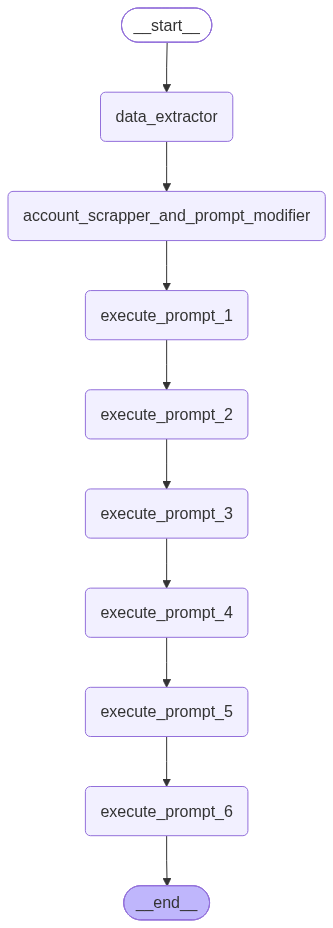

In [89]:
workflow = StateGraph(GraphState)

workflow.add_node("data_extractor", data_extractor)
workflow.add_node("account_scrapper_and_prompt_modifier", account_scrapper_and_prompt_modifier)
workflow.add_node("execute_prompt_1", execute_prompt_1)
workflow.add_node("execute_prompt_2", execute_prompt_2)
workflow.add_node("execute_prompt_3", execute_prompt_3)
workflow.add_node("execute_prompt_4", execute_prompt_4)
workflow.add_node("execute_prompt_5", execute_prompt_5)
workflow.add_node("execute_prompt_6", execute_prompt_6)

workflow.add_edge(START, "data_extractor")
workflow.add_edge("data_extractor", "account_scrapper_and_prompt_modifier")
workflow.add_edge("account_scrapper_and_prompt_modifier", "execute_prompt_1")
workflow.add_edge("execute_prompt_1", "execute_prompt_2")
workflow.add_edge("execute_prompt_2", "execute_prompt_3")
workflow.add_edge("execute_prompt_3", "execute_prompt_4")
workflow.add_edge("execute_prompt_4", "execute_prompt_5")
workflow.add_edge("execute_prompt_5", "execute_prompt_6")
workflow.add_edge("execute_prompt_6", END)

app = workflow.compile()
app


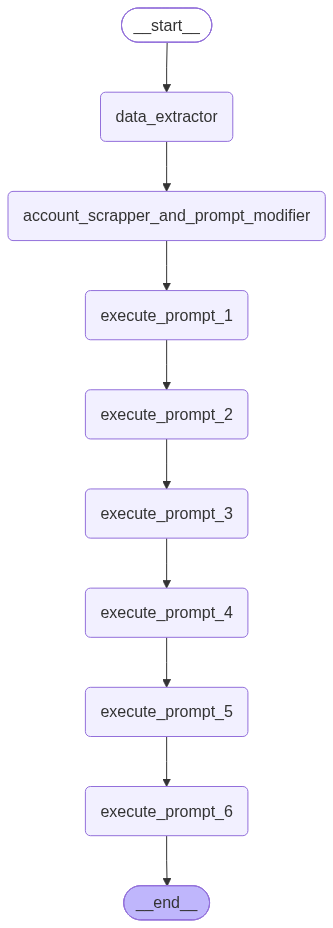

In [90]:
# Visualize the compiled graph (requires graphviz / mermaid support in the environment)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render graph image:", e)
    print(app.get_graph().draw_mermaid())


In [91]:
# Run the full SMM pipeline
pipeline_started = datetime.now()
logger.info(
    "[PIPELINE] STARTED at %s",
    pipeline_started.strftime("%Y-%m-%d %H:%M:%S"),
)
t_pipeline = time.perf_counter()

final_state = app.invoke({})

pipeline_elapsed = time.perf_counter() - t_pipeline
pipeline_ended = datetime.now()
logger.info(
    "[PIPELINE] ENDED at %s (duration: %.2fs | started: %s)",
    pipeline_ended.strftime("%Y-%m-%d %H:%M:%S"),
    pipeline_elapsed,
    pipeline_started.strftime("%Y-%m-%d %H:%M:%S"),
)

print("\n=== PIPELINE COMPLETE ===")
print("Prompt 1 preview:", (final_state.get("prompt_1_result") or "")[:300])
scripts_txt = final_state.get("output_txt_path") or ""
scripts_md = final_state.get("output_md_path") or ""
scripts_pdf = final_state.get("output_pdf_path") or ""
print(f"All Prompt 6 scripts saved to: {scripts_txt}")
if scripts_md:
    print(f"Markdown copy: {scripts_md}")
if scripts_pdf:
    print(f"PDF copy: {scripts_pdf}")
print(f"Document length: {len(final_state.get('final_document') or '')} chars")
print("Open the .txt file above to read the full script pack.")


2026-08-01 22:34:02 | INFO    | [PIPELINE] STARTED at 2026-08-01 22:34:02
2026-08-01 22:34:02 | INFO    | [Data Extractor] STARTED at 2026-08-01 22:34:02
2026-08-01 22:34:06 | INFO    | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-08-01 22:34:06 | INFO    | [Apify] skip profile scrape for unplugged.raagam — already scraped today (dna\subject\unplugged.raagam.json)
2026-08-01 22:34:06 | INFO    | [Apify] skip profile scrape for paadu_bro_official — already scraped today (dna\competitors\paadu_bro_official.json)
2026-08-01 22:34:06 | INFO    | [Apify] skip profile scrape for paata_shala — already scraped today (dna\competitors\paata_shala.json)
2026-08-01 22:34:06 | INFO    | [Apify] skip profile scrape for chinna_viramam — already scraped today (dna\competitors\chinna_viramam.json)
2026-08-01 22:34:06 | INFO    | [Data Extractor] subject=unplugged.raagam competitors=3 important=0
2026-08-01 22:34:06 | INFO    | [Data Extractor] ENDED at 2026-08-01


=== PIPELINE COMPLETE ===
Prompt 1 preview: <!-- CONTENT_DNA_INTAKE_START -->
CONTENT DNA INTAKE
Creator Account Username: unplugged.raagam
Niche Summary: A space to sing, connect & grow ✨ 
Hosted by @__.lasya.vocals__  & @pranidhiiii 
Reg contact: 9550307874 or 9493100909
Competitor Account usernames: chinna_viramam, paadu_bro_official, paat
All Prompt 6 scripts saved to: output\20260801_223745_unplugged.raagam_viral_scripts.txt
Markdown copy: output\20260801_223745_unplugged.raagam_viral_scripts.md
PDF copy: output\20260801_223745_unplugged.raagam_viral_scripts.pdf
Document length: 61629 chars
Open the .txt file above to read the full script pack.
